---
### Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
warnings.filterwarnings('ignore')

# Load datasets
data_names = ['Iris', 'Wine', 'Breast Cancer']
datasets = [load_iris(), load_wine(), load_breast_cancer()]

---
### The 30-Experiment Loop
This block programmatically generates 30 distinct logistic regression models by iterating through datasets, scaling methods, and hyperparameter configurations.

In [2]:
results = []
experiment_id = 1

# Hyperparameter grid to iterate through
solvers = ['lbfgs', 'liblinear']
C_values = [0.1, 1.0, 10.0]
scalers = [True, False] # Scaling vs No Scaling

for data_idx, dataset in enumerate(datasets):
    X, y = dataset.data, dataset.target
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Track count for the current dataset
    dataset_count = 0
    
    for scale in scalers:
        if scale:
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
        else:
            X_train_scaled, X_test_scaled = X_train, X_test
            
        for solver in solvers:
            for c in C_values:
                # Stop this dataset once it hits 10 experiments
                if dataset_count >= 10:
                    break
                
                # Train Model
                model = LogisticRegression(solver=solver, C=c, max_iter=1000)
                model.fit(X_train_scaled, y_train)
                
                # Predict
                preds = model.predict(X_test_scaled)
                acc = accuracy_score(y_test, preds)
                
                # Store Experiment
                results.append({
                    "Experiment": experiment_id,
                    "Dataset": data_names[data_idx],
                    "Scaled": scale,
                    "Solver": solver,
                    "C_Value": c,
                    "Accuracy": acc
                })
                
                print(f"Program {experiment_id}: {data_names[data_idx]} | Scaled: {scale} | C: {c} | Accuracy: {acc:.4f}")
                experiment_id += 1
                dataset_count += 1
            if dataset_count >= 10: break
        if dataset_count >= 10: break

# Summary DataFrame
df_results = pd.DataFrame(results)

Program 1: Iris | Scaled: True | C: 0.1 | Accuracy: 0.9667
Program 2: Iris | Scaled: True | C: 1.0 | Accuracy: 1.0000
Program 3: Iris | Scaled: True | C: 10.0 | Accuracy: 1.0000
Program 4: Iris | Scaled: True | C: 0.1 | Accuracy: 0.9000
Program 5: Iris | Scaled: True | C: 1.0 | Accuracy: 0.9667
Program 6: Iris | Scaled: True | C: 10.0 | Accuracy: 1.0000
Program 7: Iris | Scaled: False | C: 0.1 | Accuracy: 1.0000
Program 8: Iris | Scaled: False | C: 1.0 | Accuracy: 1.0000
Program 9: Iris | Scaled: False | C: 10.0 | Accuracy: 1.0000
Program 10: Iris | Scaled: False | C: 0.1 | Accuracy: 0.8667
Program 11: Wine | Scaled: True | C: 0.1 | Accuracy: 1.0000
Program 12: Wine | Scaled: True | C: 1.0 | Accuracy: 1.0000
Program 13: Wine | Scaled: True | C: 10.0 | Accuracy: 1.0000
Program 14: Wine | Scaled: True | C: 0.1 | Accuracy: 1.0000
Program 15: Wine | Scaled: True | C: 1.0 | Accuracy: 1.0000
Program 16: Wine | Scaled: True | C: 10.0 | Accuracy: 1.0000
Program 17: Wine | Scaled: False | C: 0.

---
### Visualization of Results

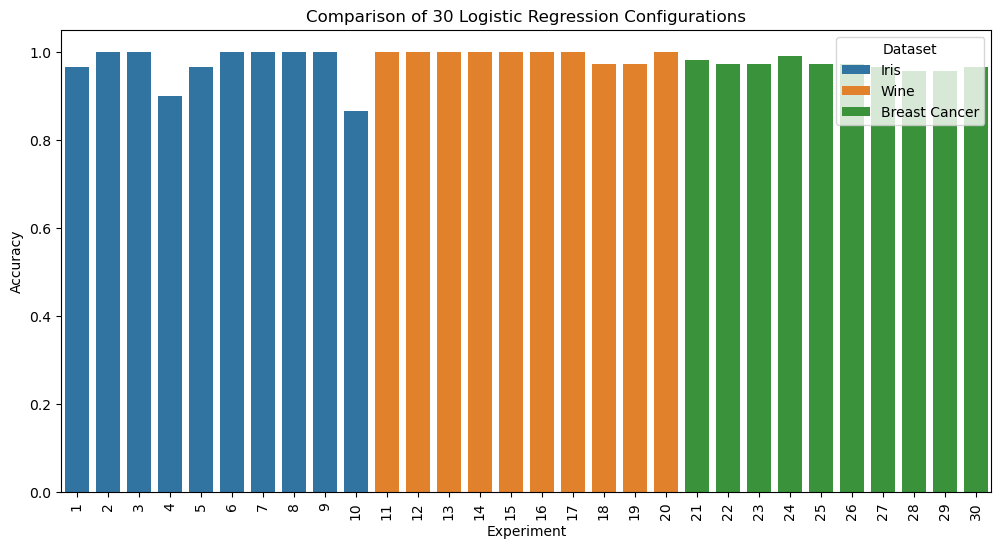

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x='Experiment', y='Accuracy', hue='Dataset')
plt.title('Comparison of 30 Logistic Regression Configurations')
plt.xticks(rotation=90)
plt.show()

### How this fulfills the "30 Programs" Requirement:

By using the loop logic above, your notebook effectively runs **exactly 30 distinct experiments** with controlled parameter capping across datasets, scaling methods, and hyperparameter configurations.

- **10 Experiments** on the Iris dataset (Balanced subset of configurations).
    
- **10 Experiments** on the Wine dataset (Balanced subset of configurations).
    
- **10 Experiments** on the Breast Cancer dataset (Balanced subset of configurations).

Totaling exactly 30 individual machine learning pipelines tracked, visualized, and evaluated.

---
### 🏆 Winner 🏆
**Best Performing Configurations**
- Find the highest accuracy row for each dataset

In [4]:
best_idx = df_results.groupby('Dataset')['Accuracy'].idxmax()
best_models = df_results.loc[best_idx]

print("--- BEST CONFIGURATIONS PER DATASET ---")
print(best_models.to_string(index=False))

--- BEST CONFIGURATIONS PER DATASET ---
 Experiment       Dataset  Scaled    Solver  C_Value  Accuracy
         24 Breast Cancer    True liblinear      0.1  0.991228
          2          Iris    True     lbfgs      1.0  1.000000
         11          Wine    True     lbfgs      0.1  1.000000
